# Investigate data from 80K 
- data from old assignment process with standard config (10bc, 1 DNA, 1 RNA)
- data from new assignment process with standard config (10bc, 1 DNA, 1 RNA)
- compare the number of sequences found in `cardiac_neuro_cava_random`


In [1]:
import pandas as pd
import yaml

# config
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/config/config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

### compare low config vs standard config results
- standard: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/standard_NGN2_filtered_counts_sequences.tsv.gz`
- lowConfig: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_filtered_counts_sequences.tsv.gz`

In [5]:
# standard:
standard_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/standard_NGN2_filtered_counts_sequences.tsv.gz'  
lowConfig_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_filtered_counts_sequences.tsv.gz'  
# standard_mspra_result = pd.read_csv(standard_path, sep='\t')
lowConfig_mpra_result = pd.read_csv(lowConfig_path, sep='\t')

In [4]:
standard_mpra_result.variant_id.nunique() # 42129
lowConfig_mpra_result.variant_id.nunique() # 42129

42129

### compare assignment process (no config used and new assignment table path seems to be wrong)

In [3]:
old_assignment_table_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesign/assignment_barcodes.standardConfig.sorted.tsv.gz"

old_assignment_table =  pd.read_csv(old_assignment_table_path, sep="\t", header=None)
old_assignment_table.columns = ["barcode", "header", "info", "count"]
old_assignment_table # 7078311 

NameError: name 'old_assignmnet_table' is not defined

In [9]:
new_assignment_table_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assignment/assignmentFixDuplicates.tsv.gz"

new_assignment_table =  pd.read_csv(new_assignment_table_path, sep="\t", header=None) # 6601484 
new_assignment_table.columns = ["barcode", "header", "info", "count"]
new_assignment_table # 6102132

In [12]:
new_assignment_table["header"].str.contains("cardiac_neuro_cava_random").sum()

6102132

In [8]:
# investigate how many rows contain cardiac_neuro_cava_random in header
old_assignment_table["header"].str.contains("cardiac_neuro_cava_random").sum() # 6547342

new_ass

6547342

## Investigate varitan_region_map
- current list of problems:
  - How to prepare a very good overview over the data
  - Why do we have only 26k regions with ref and alt? 
    - is it because of the variant_region_map?

In [149]:
import pandas as pd
import yaml

import sys 

from importlib import reload

# config
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()
    
sys.path.append('/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/00_helpful_functions')
import helpful_functions as hf
# reload helpful_functions
reload(hf)



<module 'helpful_functions' from '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/00_helpful_functions/helpful_functions.py'>

In [150]:
# variant_region_map:
# var_reg_map_path = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/design/final_design/results/final_design/cardiac_neuro_cava_random/variant_region_map.tsv.gz"
var_reg_map_path = config["files"]["final_design"]["variant_table_duplicates"]
varaint_region_map = pd.read_csv(var_reg_map_path, sep="\t")
varaint_region_map

# check if all variants do have cava in name
var_reg_map_label = varaint_region_map["Variant"].str.split(":").str[0]
var_reg_map_label.value_counts() # cardiac_neuro_cava_random    46374

# design file: 
design_df = hf.fasta_to_dataframe(config["files"]["final_design"]["design_fasta"])
design_df
# split header at ":" and take the first part in a new column called label
design_df["label"] = design_df["header"].str.split(":").str[0]
cardiac_neuro_cava_random_df = design_df[design_df["label"] == "cardiac_neuro_cava_random"]
# drop label column
cardiac_neuro_cava_random_df = cardiac_neuro_cava_random_df.drop(columns=["label"])
cardiac_neuro_cava_random_df

# design file with duplicates
design_df_dup = hf.fasta_to_dataframe(config["files"]["final_design"]["design_with_duplicates"])
design_df_dup
# split header at ":" and take the first part in a new column called label
design_df_dup["label"] = design_df_dup["header"].str.split(":").str[0]
dup_cardiac_neuro_cava_random_df = design_df_dup[design_df_dup["label"] == "cardiac_neuro_cava_random"]
# drop label column
dup_cardiac_neuro_cava_random_df = dup_cardiac_neuro_cava_random_df.drop(columns=["label"])
dup_cardiac_neuro_cava_random_df


,header,sequence
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTAAGAATACAAGTAACTGATGAATGAAGGGGG...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTTTGGGTATGCTGCCCCCCAGCTGGCGGGGCA...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTACGAGCAAGGGAATGAGAGAGAGTGGGTTAG...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCGTGGACACGCGTGATTGACCCTTTAACTGT...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCCGGAGAGTCTCAGCTCCCGCAGCCCTAACA...
...,...,...
73935,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGGACCGGATCAACTGGAGCTCTGCCTCACCCCACCTGGCCCCAAT...
73936,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGGACCGGATCAACTATGTCTGAATTCACCTCCAAATAATGGGAAA...
73937,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGGACCGGATCAACTCCTCTGCCCTCCCTGGCTTCTTCCCCTGTCC...
73938,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGGACCGGATCAACTCCTCTGCCCTCCCTGGCTTCTTCCCCTGTCC...


In [131]:
varaint_region_map

,Variant,Region,REF_ID,ALT_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...,...
46369,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46370,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46371,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46372,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


#### Check deduplicated design file: manually matching with variant region map
- check if the variant region map is correct
- have na values for 778 reference => all these differences are because "," was changed to "~"
- have na value for 1374 alt

In [132]:
# left join of varaint_region_map (on Variant) with cardiac_neuro_cava_random_df (on Header) (assumption if everything is fine: variant region map is a subset of cardiac_neuro_cava_random_df)
variant_region_map_var_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="Variant", right_on="header", how="left")
variant_region_map_region_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="Region", right_on="header", how="left")
variant_region_map_ref_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="REF_ID", right_on="header", how="left")
variant_region_alt_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="ALT_ID", right_on="header", how="left")
# # how many rows have NA in sequence column
# variant_region_map_merged["sequence"].isna().sum() # 46374

In [133]:
variant_region_map_var_merged["sequence"].isna().sum() # 46374
variant_region_map_region_merged["sequence"].isna().sum() # 46374
variant_region_map_ref_merged["sequence"].isna().sum() # 778
variant_region_alt_merged["sequence"].isna().sum() # 1374

1374

In [135]:
alt_not_in_new_design = variant_region_alt_merged[variant_region_alt_merged["sequence"].isna()]
ref_not_in_new_design = variant_region_map_ref_merged[variant_region_map_ref_merged["sequence"].isna()]

#### Investigate the ref_id changes: all are "," to "~" changes
- final script: /data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/01_missing_sequences/scripts/modify_variant_table.py

In [136]:
# 1. replace ref_id with sequence from design_df_dup
count = 0
comma_to_tilde = 0
column = "REF_ID"
same_sequence = 0

for i, row in ref_not_in_new_design.iterrows():
    count += 1
    ref_id = row[column]
    sequence = dup_cardiac_neuro_cava_random_df[dup_cardiac_neuro_cava_random_df["header"] == ref_id]["sequence"].values[0]
    new_ref_id = cardiac_neuro_cava_random_df[cardiac_neuro_cava_random_df["sequence"] == sequence]["header"].values[0]
    # check if sequence is unique
    if sequence in sequences:
        same_sequence += 1
    
    # # debug
    # print(ref_id)
    # print(sequence)
    # print(new_ref_id)
    # # find number of differences between the two sequences
    different_positions = [i for i in range(len(ref_id)) if ref_id[i] != new_ref_id[i]]
    if ref_id[different_positions[0]] == ",":
        comma_to_tilde += 1
    varaint_region_map.at[i, column] = new_ref_id

print(comma_to_tilde)
print("Same sequence: ", same_sequence)

778
Same sequence:  0


In [137]:
# Iterate the ref_id column in the variant_region_map and replace it with the sequence of the design_df_dup and replace in a subsequent step the sequence with the header from the design_df of the sequence (repeat the same with the ALT_ID)
# 1. replace ref_id with sequence from design_df_dup
count = 0
comma_to_tilde = 0
column = "ALT_ID"
sequences = []
same_sequence = 0
for i, row in alt_not_in_new_design.iterrows():
    count += 1

    ref_id = row[column]
    sequence = dup_cardiac_neuro_cava_random_df[dup_cardiac_neuro_cava_random_df["header"] == ref_id]["sequence"].values[0]
    new_ref_id = cardiac_neuro_cava_random_df[cardiac_neuro_cava_random_df["sequence"] == sequence]["header"].values[0]
    if sequence in sequences:
        same_sequence += 1
    # # debug
    # print(ref_id)
    # print(sequence)
    # print(new_ref_id)
    sequences.append(sequence)
    # # find number of differences between the two sequences
    different_positions = [i for i in range(len(ref_id)) if ref_id[i] != new_ref_id[i]]
    if ref_id[different_positions[0]] == ",":
        comma_to_tilde += 1
    # varaint_region_map.at[i, column] = new_ref_id
    # if count > 5:
    #     break

print("Checked rows: ", count)
print("Found comma to tilde changed: ", comma_to_tilde)
print("Same sequence: ", same_sequence)
# 2. replace sequence with header from design_df



Checked rows:  1374
Found comma to tilde changed:  1374
Same sequence:  0


In [114]:
variant_region_map_ref_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="REF_ID", right_on="header", how="left")
variant_region_map_ref_merged["sequence"].isna().sum() # 0 because changed the "," to "~"

0

In [120]:
variant_region_alt_merged = varaint_region_map.merge(cardiac_neuro_cava_random_df, left_on="ALT_ID", right_on="header", how="left")
variant_region_alt_merged["sequence"].isna().sum() # 0 because changed the "," to "~"

0

### Investigate the MPRAsnakeflow output for variants with log2FC values
- `/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/assigned_counts/assignmentFixDuplicates/lowConfig/NGN2_allreps_merged.combined.tsv.gz`

In [2]:
import pandas as pd
allreps_merged_combined = '/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/assigned_counts/assignmentFixDuplicates/lowConfig/NGN2_allreps_merged.combined.tsv.gz'
allreps_df = pd.read_csv(allreps_merged_combined, sep="\t")

In [3]:
new_variant_region_map = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/80K_MPRA/design/variant_region_map_deduplicated.tsv.gz"
new_variant_reg_df = pd.read_csv(new_variant_region_map, sep="\t") # 46374 rows
new_variant_reg_df

,Variant,Region,REF_ID,ALT_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...,...
46369,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46370,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46371,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
46372,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


In [4]:
possible_variants = allreps_df[allreps_df["Label"] == "cardiac_neuro_cava_random"]
possible_variants # 69210 
possible_variants["name"].nunique() # 69210
# join possible variants (name) with the new_variant_reg_df (Variant)

possible_variants_merged = possible_variants.merge(new_variant_reg_df, left_on="name", right_on="Variant", how="left")


In [5]:
possible_variants_merged["REF_ID"].isna().sum() # 0

69210

#### Check the variant region map with the design with duplicates => sanity check if something else is wrong with the variant region map
- check if the variant region map is correct => no NAs for ref and alt => all ids in the design

In [52]:
dup_variant_region_map_var_merged = varaint_region_map.merge(dup_cardiac_neuro_cava_random_df, left_on="Variant", right_on="header", how="left")
dup_variant_region_map_region_merged = varaint_region_map.merge(dup_cardiac_neuro_cava_random_df, left_on="Region", right_on="header", how="left")
dup_variant_region_map_ref_merged = varaint_region_map.merge(dup_cardiac_neuro_cava_random_df, left_on="REF_ID", right_on="header", how="left")
dup_variant_region_alt_merged = varaint_region_map.merge(dup_cardiac_neuro_cava_random_df, left_on="ALT_ID", right_on="header", how="left")

# variant region map nas
print("Na values from: var_merged: %d" % (dup_variant_region_map_var_merged["sequence"].isna().sum())) # 46374
print("Na values from: ion_merged: %d" % (dup_variant_region_map_region_merged["sequence"].isna().sum())) # 46374
print("Na values from: ref_merged: %d" % (dup_variant_region_map_ref_merged["sequence"].isna().sum())) # 778
print("Na values from: alt_merged: %d" % (dup_variant_region_alt_merged["sequence"].isna().sum())) # 1374

# Na values from: var_merged: 46374
# Na values from: ion_merged: 46374
# Na values from: ref_merged: 0
# Na values from: alt_merged: 0

Na values from: var_merged: 46374
Na values from: ion_merged: 46374
Na values from: ref_merged: 0
Na values from: alt_merged: 0


## Invastigate the design difference
- goal: table of new header vs list of old header with the same sequence
- Find number of headers with the same sequence in duplicates design
- create a table between the two designs if the sequence is the same and create a list of headers if it is the same for multiple headers/sequences

In [1]:
import pandas as pd
# I have the two design files one has duplicated sequences: 
# design file: 
design_df = hf.fasta_to_dataframe(config["files"]["final_design"]["design_fasta"])
design_df
# split header at ":" and take the first part in a new column called label
design_df["label"] = design_df["header"].str.split(":").str[0]
# cardiac_neuro_cava_random_df = design_df[design_df["label"] == "cardiac_neuro_cava_random"]
# drop label column
cardiac_neuro_cava_random_df = cardiac_neuro_cava_random_df.drop(columns=["label"])
cardiac_neuro_cava_random_df

# design file with duplicates
design_df_dup = hf.fasta_to_dataframe(config["files"]["final_design"]["design_with_duplicates"])
design_df_dup
# split header at ":" and take the first part in a new column called label
design_df_dup["label"] = design_df_dup["header"].str.split(":").str[0]
# dup_cardiac_neuro_cava_random_df = design_df_dup[design_df_dup["label"] == "cardiac_neuro_cava_random"]
# drop label column
dup_cardiac_neuro_cava_random_df = dup_cardiac_neuro_cava_random_df.drop(columns=["label"])
dup_cardiac_neuro_cava_random_df

NameError: name 'hf' is not defined

In [61]:
# create dict of sequence to header from the duplicated design file
from collections import defaultdict
design_dict = defaultdict(list)
for i, row in design_df_dup.iterrows():
    design_dict[row["sequence"]].append(row["header"])

# find maximal number of entries in the dict values
[max(len(v) for v in design_dict.values())]


[4]

In [65]:
# get all sequences and headers with more than one entry in duplicated_sequences.values()
duplicated_sequences = {k: v for k, v in design_dict.items() if len(v) > 1} 
duplicated_sequences # 344
# len(duplicated_sequences)
# iterate over duplicated_sequences values (header) and get the corresponding label + count them
dup_seq_label_counts = defaultdict(int)
for k, v in duplicated_sequences.items():
    for header in v:
        label = header.split(":")[0]
        dup_seq_label_counts[label] += 1
        
# result is the number of duplicated sequences for each label
dup_seq_label_counts

# defaultdict(int,
#             {'GC_Selvarajan': 6,
#              'GC_Mohlke': 6,
#              'C_positive_heart_CAD': 2,
#              'GC_Mendelian_variants': 28,
#              'GC_GABA_Chengyu': 46,
#              'GC_Glut_Chengyu': 43,
#              'MK': 751,
#              'C_positive_neuron_CD': 3,
#              'C_negative_heart_MK': 12,
#              'C_negative_neuron_MK': 18,
#              'C_positive_heart_MK': 6,
#              'C_positive_neuron_MK': 14})

defaultdict(int,
            {'GC_Selvarajan': 6,
             'GC_Mohlke': 6,
             'C_positive_heart_CAD': 2,
             'GC_Mendelian_variants': 28,
             'GC_GABA_Chengyu': 46,
             'GC_Glut_Chengyu': 43,
             'MK': 751,
             'C_positive_neuron_CD': 3,
             'C_negative_heart_MK': 12,
             'C_negative_neuron_MK': 18,
             'C_positive_heart_MK': 6,
             'C_positive_neuron_MK': 14})

## Check bed and vcf files 
- are there sequences in the bed file with length >350 bp? - Max is 350 bp => NO => No tiling in 80K
- 

Length of bed file:  31092


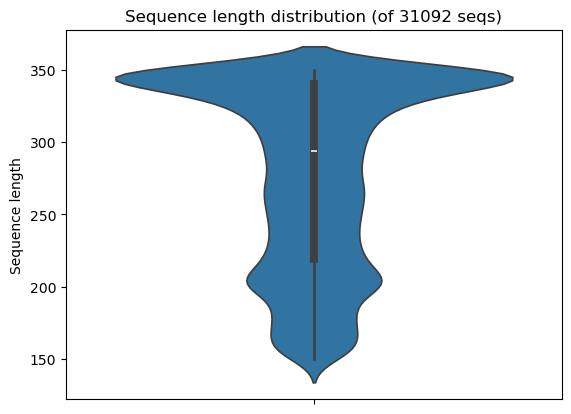

In [21]:
bed_file = pd.read_csv(config["files"]["final_design"]["bed_file"], sep="\t", header=None)
bed_file
print("Length of bed file: ", bed_file.shape[0]) # (31092, 6)
bed_file.columns = ["chr", "start", "end", "ID", "score", "strand"]
bed_file["seq_length"] = bed_file["end"] - bed_file["start"]

bed_file["seq_length"].max() # 350
bed_file["seq_length"].value_counts()
# 350    1353
# 349    1104
# 348     931
# 347     798
# 346     727
#        ... 
# 183      79
# 245      78
# 152      77
# 174      77
# 185      76


# I would like to have a violine box plot of the sequence length distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=bed_file["seq_length"])
# add title and y label title
plt.title(f"Sequence length distribution (of {bed_file.shape[0]} seqs)")
plt.ylabel("Sequence length")
# save the plot
output_path = config["files"]["output"]["plotting"] + "designed_seq_length_distribution_violin.png"
plt.savefig(output_path)

plt.show()

